# Hybrid LegWheel ICRA Note

這份 notebook 是 `hybrid_note` 的互動展示入口。每一段都直接 call `hybrid_note/scripts/` 裡整理好的 function，從 notebook 內選參數、run、存到 `outputs/`，並且把剛生成的圖直接顯示在 cell output。

原則：不複製完整程式碼進 notebook，只保留參數、function call、結果呈現。

## Env Setup

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path
import csv
import os
import sys
import tempfile

from IPython.display import Markdown, display
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "legwheel_matplotlib"))
import matplotlib.pyplot as plt
import numpy as np

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in [CWD, *CWD.parents] if (path / "legwheel").exists())
NOTE_ROOT = PROJECT_ROOT / "hybrid_note"

for path in [PROJECT_ROOT, NOTE_ROOT / "scripts" / "kinematics", NOTE_ROOT / "scripts" / "analysis"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

FIG_KIN = NOTE_ROOT / "outputs" / "figures" / "kinematics"
TAB_KIN = NOTE_ROOT / "outputs" / "tables" / "kinematics"
FIG_ANA = NOTE_ROOT / "outputs" / "figures" / "analysis"
TAB_ANA = NOTE_ROOT / "outputs" / "tables" / "analysis"
DATA_ANA = NOTE_ROOT / "outputs" / "data" / "analysis"

for folder in [FIG_KIN, TAB_KIN, FIG_ANA, TAB_ANA, DATA_ANA]:
    folder.mkdir(parents=True, exist_ok=True)

from plot_leg_2d import plot_xy
from plot_leg_3d import plot_3d
from ground_contact_single_pose import (
    CONTACT_HEIGHT_TOL,
    compute_ground_contact,
    write_contact_points_csv,
    write_contact_summary_csv,
)
from ground_contact_pose_3d import (
    LATERAL_SAMPLES as CONTACT_3D_LATERAL_SAMPLES,
    compute_ground_contact_pose_3d,
    write_contact_points_csv as write_contact_points_csv_3d,
    write_contact_summary_csv as write_contact_summary_csv_3d,
)
from rim_contact_parameter_scan import (
    CONTACT_Z_TOL as SCAN_CONTACT_Z_TOL,
    CONTACT_STATE_ORDER,
    CONTACT_STATE_COLORS as GAMMA_COMPARISON_STATE_COLORS,
    RIM_SURFACES,
    aggregate_ranges,
    plot_contact_map_2d,
    plot_contact_map_3d,
    scan_parameter_grid,
    write_csv,
)
from ground_contact_state_map import (
    CONTACT_HEIGHT_TOL as STATE_MAP_CONTACT_HEIGHT_TOL,
    CONTACT_STATE_ORDER as STATE_MAP_CONTACT_STATE_ORDER,
    RIM_ARC_SAMPLES as STATE_MAP_RIM_ARC_SAMPLES,
    detect_state_boundaries,
    generate_contact_state_map,
    plot_contact_state_map,
    save_contact_map_csv,
)
from ground_contact_state_map_3d import (
    CONTACT_HEIGHT_TOL as STATE_MAP_3D_CONTACT_HEIGHT_TOL,
    CONTACT_STATE_ORDER as STATE_MAP_3D_CONTACT_STATE_ORDER,
    LATERAL_SAMPLES as STATE_MAP_3D_LATERAL_SAMPLES,
    RIM_ARC_SAMPLES as STATE_MAP_3D_RIM_ARC_SAMPLES,
    generate_contact_state_map_3d,
    plot_contact_state_map_3d,
    save_contact_map_csv_3d,
)
from ground_contact_state_map_fast import (
    detect_class_boundaries_fast,
    generate_contact_state_map_fast,
    plot_contact_state_map_fast,
    save_contact_map_npz_fast,
)
from ground_contact_state_map_3d_fast import (
    generate_contact_state_map_3d_fast,
    plot_contact_state_map_3d_fast,
    save_contact_map_npz_3d_fast,
)
from compare_ground_contact_gamma import (
    generate_gamma_comparison,
    plot_gamma_comparison,
    save_gamma_comparison_npz,
    save_gamma_comparison_summary_csv,
)

def display_saved_fig(fig, path):
    if fig is None:
        display(Markdown("No figure returned."))
        return
    fig.canvas.draw()
    display(fig)
    display(Markdown(f"Saved: `{path.relative_to(PROJECT_ROOT)}`"))
    plt.close(fig)

def show_csv(path, limit=10):
    path = Path(path)
    if not path.exists():
        display(Markdown(f"Missing table: `{path}`"))
        return
    try:
        import pandas as pd
        display(pd.read_csv(path).head(limit))
    except Exception:
        with path.open(newline="") as csv_file:
            display(list(csv.DictReader(csv_file))[:limit])

print("PROJECT_ROOT =", PROJECT_ROOT)
print("NOTE_ROOT    =", NOTE_ROOT)

PROJECT_ROOT = /home/chang/corgi_ws/icra hybrid/LegWheel
NOTE_ROOT    = /home/chang/corgi_ws/icra hybrid/LegWheel/hybrid_note


# 1. Current Leg Geometry

## 1.1 2D Leg Plane

在這格改參數，下一格直接 call `plot_xy()`，存 PNG/CSV，也把剛生成的 figure 顯示在 notebook。

In [21]:
theta_2d_deg = 80.0
beta_2d_deg = -170.0
alpha_2d_deg = 0.0
w_2d_m = 0.0

leg_2d_png = FIG_KIN / f"leg_2d_theta{theta_2d_deg:g}_beta{beta_2d_deg:g}.png"
leg_2d_csv = TAB_KIN / f"leg_2d_theta{theta_2d_deg:g}_beta{beta_2d_deg:g}.csv"

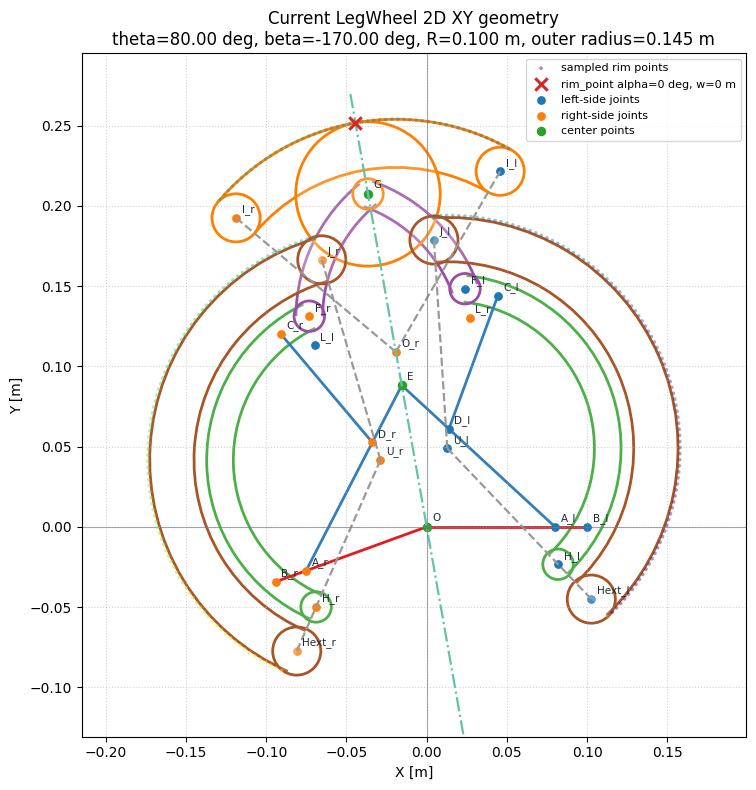

Saved: `hybrid_note/outputs/figures/kinematics/leg_2d_theta80_beta-170.png`

,point,x_m,y_m
0,O,0.000000,0.000000
1,A_l,0.080000,-0.000000
2,A_r,-0.075175,-0.027362
3,B_l,0.100000,-0.000000
4,B_r,-0.093969,-0.034202
5,C_l,0.044286,0.143917
6,C_r,-0.090838,0.120091
7,D_l,0.013854,0.061030


In [22]:
joints_2d, fig = plot_xy(
    theta_deg=theta_2d_deg,
    beta_deg=beta_2d_deg,
    alpha_deg=alpha_2d_deg,
    w_m=w_2d_m,
    output_png=leg_2d_png,
    output_csv=leg_2d_csv,
    return_fig=True,
)
display_saved_fig(fig, leg_2d_png)
show_csv(leg_2d_csv, limit=8)

## 1.2 3D Geometry and Projections

這裡可以改 `theta/beta/gamma`，直接生成 3D、leg plane view、YZ projection 三張合在一起的圖。

In [4]:
theta_3d_deg = 17.0
beta_3d_deg = 45.0
gamma_3d_deg = 10.0
alpha_3d_deg = 0.0

leg_3d_png = FIG_KIN / f"leg_3d_theta{theta_3d_deg:g}_beta{beta_3d_deg:g}_gamma{gamma_3d_deg:g}.png"
leg_3d_csv = TAB_KIN / f"leg_3d_theta{theta_3d_deg:g}_beta{beta_3d_deg:g}_gamma{gamma_3d_deg:g}.csv"

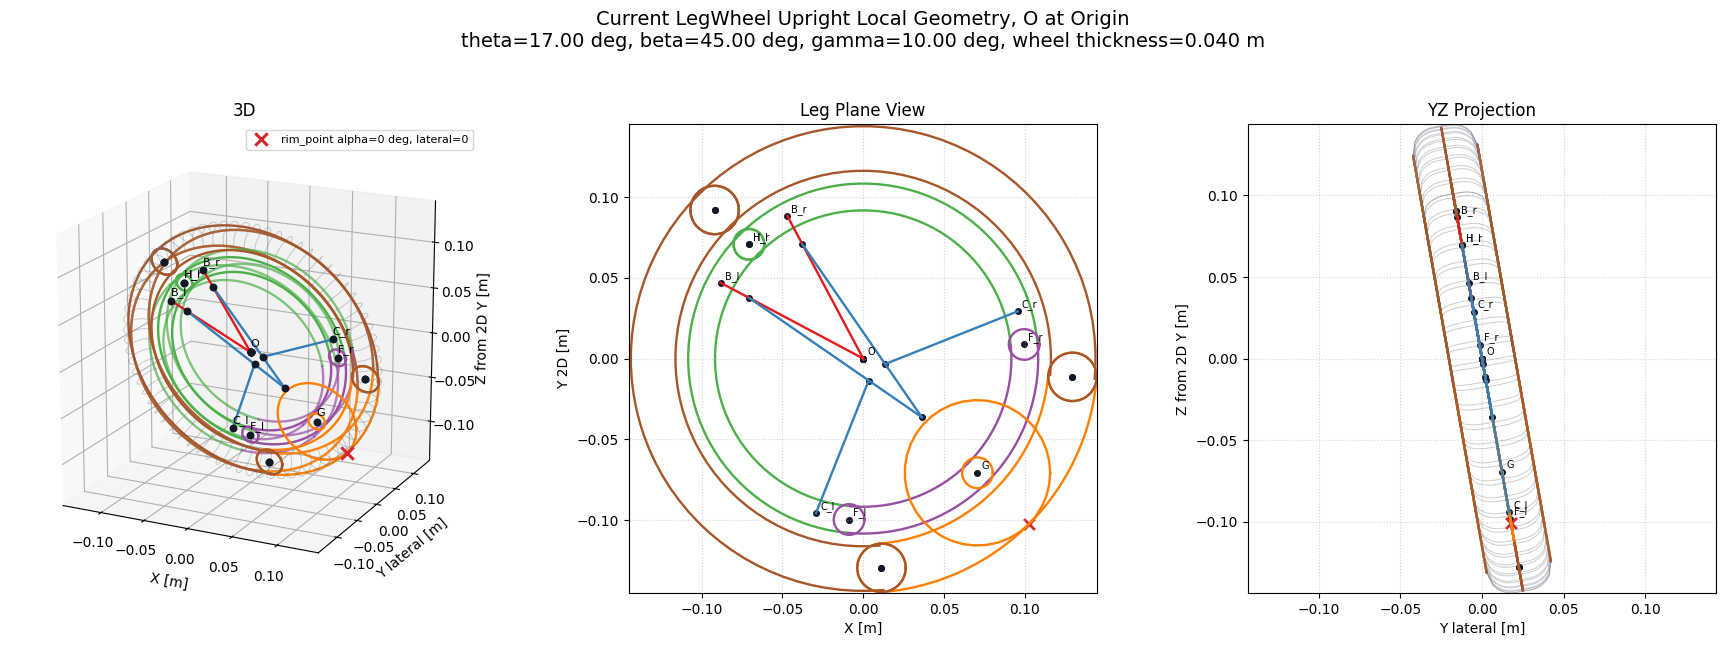

Saved: `hybrid_note/outputs/figures/kinematics/leg_3d_theta17_beta45_gamma10.png`

,point,x_m,y_2d_m,lateral_m
0,O,0.000000,0.000000,0.0
1,A_l,-0.070636,0.037558,0.0
2,A_r,-0.037558,0.070636,0.0
3,B_l,-0.088295,0.046947,0.0
4,B_r,-0.046947,0.088295,0.0
5,C_l,-0.029237,-0.095630,0.0
6,C_r,0.095630,0.029237,0.0
7,D_l,0.003415,-0.013593,0.0


In [5]:
joints_3d, fig = plot_3d(
    theta_deg=theta_3d_deg,
    beta_deg=beta_3d_deg,
    gamma_deg=gamma_3d_deg,
    alpha_deg=alpha_3d_deg,
    output_png=leg_3d_png,
    output_csv=leg_3d_csv,
    return_fig=True,
)
display_saved_fig(fig, leg_3d_png)
show_csv(leg_3d_csv, limit=8)

# 2. Single-Pose Geometric Ground Contact

這裡是在 notebook 裡直接 call 2D `compute_ground_contact(theta, beta)`，輸出最低高度、candidate set，以及 contact state table。這一版先不畫圖、不考慮 gamma。

In [23]:
theta_contact_deg = 80.0
beta_contact_deg = -170.0

contact_height_tol = CONTACT_HEIGHT_TOL
arc_samples = 721
include_reference_points = False

contact_summary_csv = TAB_KIN / f"ground_contact_2d_theta{theta_contact_deg:g}_beta{beta_contact_deg:g}_summary.csv"
contact_candidates_csv = TAB_KIN / f"ground_contact_2d_theta{theta_contact_deg:g}_beta{beta_contact_deg:g}_candidates.csv"

In [24]:
theta = np.deg2rad(theta_contact_deg)
beta = np.deg2rad(beta_contact_deg)

contact = compute_ground_contact(
    theta,
    beta,
    contact_height_tol=contact_height_tol,
    arc_samples=arc_samples,
    include_reference_points=include_reference_points,
)
write_contact_summary_csv(contact_summary_csv, contact)
write_contact_points_csv(contact_candidates_csv, contact)

print("height_min/y_min =", contact["height_min"])
print("lowest point =", contact["lowest_point_x"], contact["lowest_point_y"])
print("lowest state =", contact["lowest_contact_state_label"])
print("contact states =", contact["contact_states"])
print("number_of_contact_points =", contact["number_of_contact_points"])
print("representative_contact =", contact["representative_contact_x"], contact["representative_contact_y"])
print("x_span =", contact["x_span"])
print("y_span =", contact["y_span"])

show_csv(contact_summary_csv, limit=5)
show_csv(contact_candidates_csv, limit=8)

height_min/y_min = -0.09005602698043265
lowest point = -0.08652315640950789 -0.09005602698043265
lowest state = non_contact_region
contact states = right_rim;non_contact_region
number_of_contact_points = 6
representative_contact = -0.08763753581851207 -0.08955942604196786
x_span = 0.002226500326460157
y_span = 0.0009982392785601035


,theta,beta,theta_deg,beta_deg,contact_height_tol,arc_samples,include_reference_points,height_min,y_min,lowest_point_x,...,dominant_contact_state_id,dominant_contact_state_label,representative_contact_x,representative_contact_y,x_min,x_max,x_span,y_contact_min,y_contact_max,y_span
0,1.396263,-2.96706,80.0,-170.0,0.001,721,False,-0.090056,-0.090056,-0.086523,...,R,right_rim,-0.087638,-0.089559,-0.08875,-0.086523,0.002227,-0.090056,-0.089058,0.000998


,point_index,geometry_type,surface_name,surface_description,contact_state,contact_state_id,contact_state_label,arc_sample_index,arc_angle_deg,surface_center_x_m,surface_center_y_m,x_m,y_m
0,2157,rim_arc,upper_tyre_r,right upper tyre outer arc,right_rim,R,right_rim,715,245.365070,-0.028809,0.041654,-0.088750,-0.089058
1,2158,rim_arc,upper_tyre_r,right upper tyre outer arc,right_rim,R,right_rim,716,245.559515,-0.028809,0.041654,-0.088306,-0.089260
2,2159,rim_arc,upper_tyre_r,right upper tyre outer arc,right_rim,R,right_rim,717,245.753959,-0.028809,0.041654,-0.087861,-0.089462
3,2160,rim_arc,upper_tyre_r,right upper tyre outer arc,right_rim,R,right_rim,718,245.948404,-0.028809,0.041654,-0.087416,-0.089661
4,2161,rim_arc,upper_tyre_r,right upper tyre outer arc,right_rim,R,right_rim,719,246.142848,-0.028809,0.041654,-0.086970,-0.089859
5,2162,rim_arc,upper_tyre_r,right upper tyre outer arc,non_contact_region,N,non_contact_region,720,246.337292,-0.028809,0.041654,-0.086523,-0.090056


# 3. Single-Pose 3D Ground Contact

這裡是在 notebook 裡直接 call `compute_ground_contact_pose_3d(theta, beta, gamma)`。目前先不畫圖，只輸出 3D 外表面最低高度、contact candidate set，以及四類 contact state。

四類分類沿用 2D 定義：`foot_rim (F)`、`left_rim (L)`、`right_rim (R)`、`non_contact_region (N)`。

接觸幾何只使用三段實際輪胎外緣：`foot_rim -> foot_rim`、`upper_tyre_l -> left_rim`、`upper_tyre_r -> right_rim`。模型內部屬性 `upper_rim_l_f/r_f` 是這兩段 Upper_Tyre 的舊名稱；綠色 Upper_Rim、紫色 Lower_Rim 都是機構結構弧，不納入 contact candidate。`non_contact_region` 只表示左右 Upper_Tyre 上端之間的開口，並以兩個 gap-facing 端點作為 contact-map 的支撐方向邊界，不是一段可接觸 rim。


In [8]:
theta_contact_3d_deg = 17.0
beta_contact_3d_deg = 45.0
gamma_contact_3d_deg = 10.0

contact_3d_height_tol = CONTACT_HEIGHT_TOL
contact_3d_arc_samples = 181  # use 721 for the same dense rim sampling as the script default
contact_3d_lateral_samples = 11  # use CONTACT_3D_LATERAL_SAMPLES for full wheel-width sampling
contact_3d_include_reference_points = False

contact_3d_summary_csv = TAB_KIN / f"ground_contact_3d_theta{theta_contact_3d_deg:g}_beta{beta_contact_3d_deg:g}_gamma{gamma_contact_3d_deg:g}_summary.csv"
contact_3d_candidates_csv = TAB_KIN / f"ground_contact_3d_theta{theta_contact_3d_deg:g}_beta{beta_contact_3d_deg:g}_gamma{gamma_contact_3d_deg:g}_candidates.csv"


In [9]:
theta_3d = np.deg2rad(theta_contact_3d_deg)
beta_3d = np.deg2rad(beta_contact_3d_deg)
gamma_3d = np.deg2rad(gamma_contact_3d_deg)

contact_3d = compute_ground_contact_pose_3d(
    theta_3d,
    beta_3d,
    gamma_3d,
    contact_height_tol=contact_3d_height_tol,
    arc_samples=contact_3d_arc_samples,
    lateral_samples=contact_3d_lateral_samples,
    include_reference_points=contact_3d_include_reference_points,
)
write_contact_summary_csv_3d(contact_3d_summary_csv, contact_3d)
write_contact_points_csv_3d(contact_3d_candidates_csv, contact_3d)

print("height_min/z_min =", contact_3d["height_min"])
print("lowest point =", contact_3d["lowest_point_x"], contact_3d["lowest_point_y"], contact_3d["lowest_point_z"])
print("lowest state =", contact_3d["lowest_contact_state_label"])
print("contact states =", contact_3d["contact_states"])
print("number_of_contact_points =", contact_3d["number_of_contact_points"])
print("representative_contact =", contact_3d["representative_contact_x"], contact_3d["representative_contact_y"], contact_3d["representative_contact_z"])
print("x_span =", contact_3d["x_span"])
print("y_span =", contact_3d["y_span"])
print("z_span =", contact_3d["z_span"])

show_csv(contact_3d_summary_csv, limit=5)
show_csv(contact_3d_candidates_csv, limit=8)


height_min/z_min = -0.14334560180872008
lowest point = 0.012611169151518591 0.017152284269683526 -0.14334560180872008
lowest state = foot_rim
contact states = foot_rim;left_rim
number_of_contact_points = 27
representative_contact = 0.009782717494497854 0.017490834968289036 -0.14270616468267655
x_span = 0.029314910403661597
y_span = 0.00821495532710231
z_span = 0.0009868349912757202


,theta,beta,gamma,theta_deg,beta_deg,gamma_deg,contact_height_tol,arc_samples,lateral_samples,include_reference_points,...,representative_contact_z,x_min,x_max,x_span,y_min,y_max,y_span,z_contact_min,z_contact_max,z_span
0,0.296706,0.785398,0.174533,17.0,45.0,10.0,0.001,181,11,False,...,-0.142706,-0.008899,0.020416,0.029315,0.012929,0.021144,0.008215,-0.143346,-0.142359,0.000987


,point_index,geometry_type,surface_name,surface_description,contact_state,contact_state_id,contact_state_label,lateral_index,lateral_m,arc_sample_index,arc_angle_deg,surface_center_x_m,surface_center_y_2d_m,local_x_m,local_y_2d_m,local_lateral_m,x_m,y_m,z_m
0,1086,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,2,-0.012,0,-85.000000,7.012838e-12,-7.012838e-12,0.012486,-0.142721,-0.012,0.012486,0.012966,-0.142637
1,1087,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,2,-0.012,1,-84.555556,7.012838e-12,-7.012838e-12,0.013593,-0.142620,-0.012,0.013593,0.012948,-0.142537
2,1088,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,2,-0.012,2,-84.111111,7.012838e-12,-7.012838e-12,0.014699,-0.142510,-0.012,0.014699,0.012929,-0.142429
3,1629,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,3,-0.008,0,-85.000000,7.012838e-12,-7.012838e-12,0.012611,-0.144146,-0.008,0.012611,0.017152,-0.143346
4,1630,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,3,-0.008,1,-84.555556,7.012838e-12,-7.012838e-12,0.013729,-0.144044,-0.008,0.013729,0.017135,-0.143245
5,1631,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,3,-0.008,2,-84.111111,7.012838e-12,-7.012838e-12,0.014846,-0.143933,-0.008,0.014846,0.017115,-0.143136
6,1632,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,3,-0.008,3,-83.666667,7.012838e-12,-7.012838e-12,0.015962,-0.143814,-0.008,0.015962,0.017095,-0.143018
7,1633,rim_surface,foot_rim,bottom foot tyre outer arc,foot_rim,F,foot_rim,3,-0.008,4,-83.222222,7.012838e-12,-7.012838e-12,0.017077,-0.143686,-0.008,0.017077,0.017072,-0.142892


# 4. Ground Contact State Map

這裡直接 call `ground_contact_state_map_fast.py` 裡的向量化 function。你可以在下一格改 theta/beta 範圍、step deg、arc samples，run 後會產生 state map 圖並直接顯示在 notebook，同時存 PNG 與 NPZ 到 `hybrid_note/outputs/`。

完整 0.1-degree map 超過 515 萬個姿態；快速版會重用同一 theta 的 geometry。CSV 因為文字列數很大不預設輸出，需要時仍可從 NPZ 轉出。

In [10]:
state_map_theta_min_deg = 17.0
state_map_theta_max_deg = 160.0
state_map_theta_step_deg = 0.1

state_map_beta_min_deg = -180.0
state_map_beta_max_deg = 180.0
state_map_beta_step_deg = 0.1

state_map_contact_height_tol = STATE_MAP_CONTACT_HEIGHT_TOL
state_map_arc_samples = 181  # use STATE_MAP_RIM_ARC_SAMPLES for full-resolution rim sampling
state_map_include_reference_points = False
state_map_dpi = 240

state_map_png = FIG_ANA / "ground_contact_state_map_theta_beta_fast_from_notebook.png"
state_map_npz = DATA_ANA / "ground_contact_state_map_theta_beta_fast_from_notebook.npz"

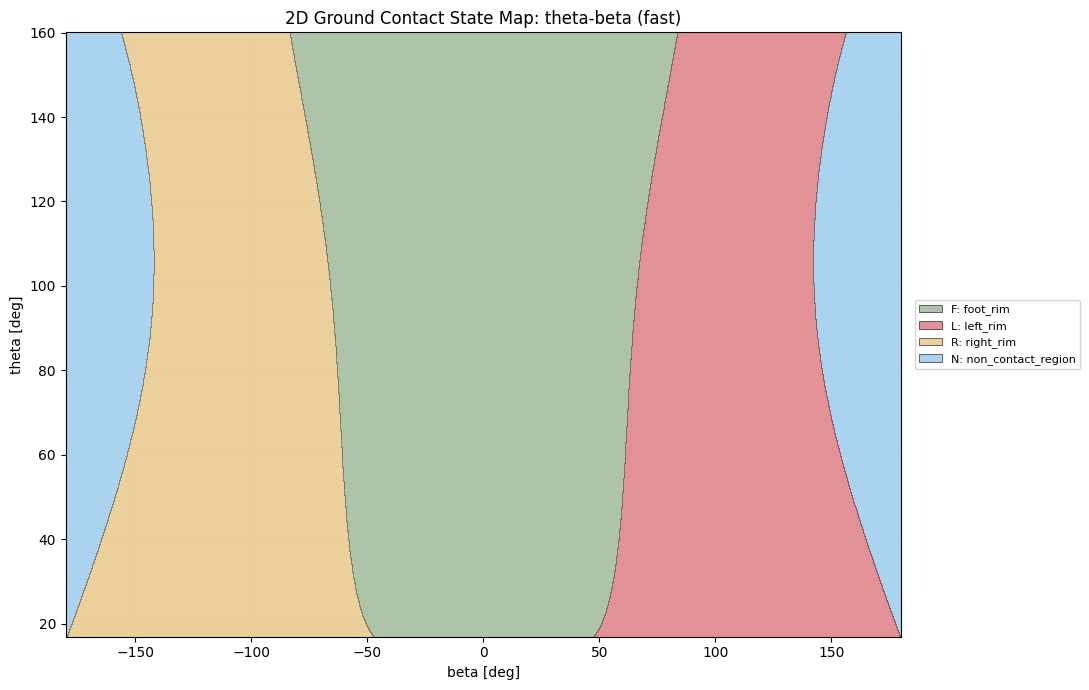

Saved: `hybrid_note/outputs/figures/analysis/ground_contact_state_map_theta_beta_fast_from_notebook.png`

Sampled poses: 5153031
Theta samples: 1431
Beta samples: 3601
Boundary segments: 7478
foot_rim: 1886195
left_rim: 1238184
right_rim: 1238184
non_contact_region: 790468
Saved NPZ: hybrid_note/outputs/data/analysis/ground_contact_state_map_theta_beta_fast_from_notebook.npz


In [11]:
state_map_data = generate_contact_state_map_fast(
    theta_min_deg=state_map_theta_min_deg,
    theta_max_deg=state_map_theta_max_deg,
    theta_step_deg=state_map_theta_step_deg,
    beta_min_deg=state_map_beta_min_deg,
    beta_max_deg=state_map_beta_max_deg,
    beta_step_deg=state_map_beta_step_deg,
    contact_height_tol=state_map_contact_height_tol,
    arc_samples=state_map_arc_samples,
    include_reference_points=state_map_include_reference_points,
)
state_map_boundaries, state_map_transition_counts = detect_class_boundaries_fast(state_map_data)
save_contact_map_npz_fast(state_map_npz, state_map_data)
fig = plot_contact_state_map_fast(
    state_map_data,
    state_map_boundaries,
    state_map_png,
    dpi=state_map_dpi,
    return_fig=True,
)
display_saved_fig(fig, state_map_png)

print(f"Sampled poses: {state_map_data['pose_count']}")
print(f"Theta samples: {len(state_map_data['theta_values'])}")
print(f"Beta samples: {len(state_map_data['beta_values'])}")
print(f"Boundary segments: {len(state_map_boundaries)}")
state_counts = np.bincount(state_map_data["class_grid"].ravel(), minlength=len(STATE_MAP_CONTACT_STATE_ORDER))
for state, count in zip(STATE_MAP_CONTACT_STATE_ORDER, state_counts):
    print(f"{state}: {int(count)}")
print(f"Saved NPZ: {state_map_npz.relative_to(PROJECT_ROOT)}")

# 5. 3D Ground Contact State Map

這裡固定一個 `gamma_deg`，但是圖仍然畫成 theta-beta 的 2D 色塊圖。快速版會為每個 theta 建立一次完整的 3D rim/lateral geometry，再一次求出所有 beta 的最低點與 contact state。

3D 仍比 2D 多出 lateral dimension；完整 0.1-degree map 可以直接跑，但改 gamma、arc samples、lateral samples 後都會重新計算。


In [12]:
state_map_3d_theta_min_deg = 17.0
state_map_3d_theta_max_deg = 160.0
state_map_3d_theta_step_deg = 0.1

state_map_3d_beta_min_deg = -180.0
state_map_3d_beta_max_deg = 180.0
state_map_3d_beta_step_deg = 0.1

state_map_3d_gamma_deg = 10.0
state_map_3d_contact_height_tol = STATE_MAP_3D_CONTACT_HEIGHT_TOL
state_map_3d_arc_samples = 181  # use STATE_MAP_3D_RIM_ARC_SAMPLES for full rim sampling
state_map_3d_lateral_samples = 11  # use STATE_MAP_3D_LATERAL_SAMPLES for full width sampling
state_map_3d_include_reference_points = False
state_map_3d_dpi = 240

state_map_3d_png = FIG_ANA / f"ground_contact_state_map_3d_theta_beta_gamma{state_map_3d_gamma_deg:g}_fast_from_notebook.png"
state_map_3d_npz = DATA_ANA / f"ground_contact_state_map_3d_theta_beta_gamma{state_map_3d_gamma_deg:g}_fast_from_notebook.npz"


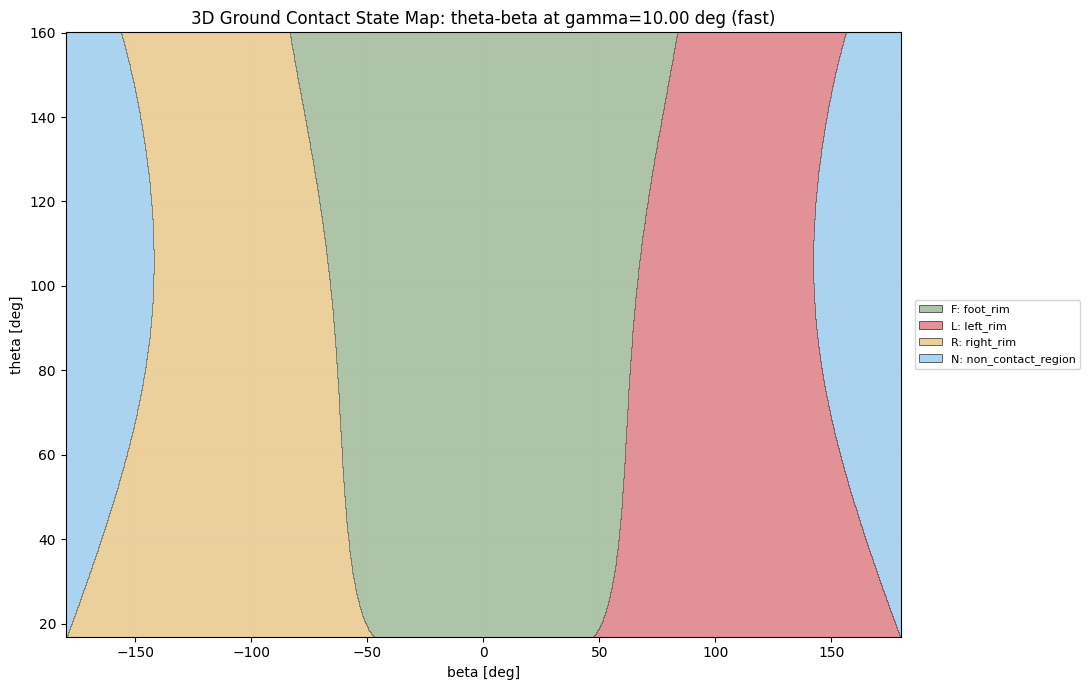

Saved: `hybrid_note/outputs/figures/analysis/ground_contact_state_map_3d_theta_beta_gamma10_fast_from_notebook.png`

Gamma: 10.0 deg
Sampled poses: 5153031
Theta samples: 1431
Beta samples: 3601
Boundary segments: 7480
foot_rim: 1886623
left_rim: 1237970
right_rim: 1237970
non_contact_region: 790468
Saved NPZ: hybrid_note/outputs/data/analysis/ground_contact_state_map_3d_theta_beta_gamma10_fast_from_notebook.npz


In [13]:
state_map_3d_data = generate_contact_state_map_3d_fast(
    theta_min_deg=state_map_3d_theta_min_deg,
    theta_max_deg=state_map_3d_theta_max_deg,
    theta_step_deg=state_map_3d_theta_step_deg,
    beta_min_deg=state_map_3d_beta_min_deg,
    beta_max_deg=state_map_3d_beta_max_deg,
    beta_step_deg=state_map_3d_beta_step_deg,
    gamma_deg=state_map_3d_gamma_deg,
    contact_height_tol=state_map_3d_contact_height_tol,
    arc_samples=state_map_3d_arc_samples,
    lateral_samples=state_map_3d_lateral_samples,
    include_reference_points=state_map_3d_include_reference_points,
)
state_map_3d_boundaries, state_map_3d_transition_counts = detect_class_boundaries_fast(state_map_3d_data)
save_contact_map_npz_3d_fast(state_map_3d_npz, state_map_3d_data)
fig = plot_contact_state_map_3d_fast(
    state_map_3d_data,
    state_map_3d_boundaries,
    state_map_3d_png,
    dpi=state_map_3d_dpi,
    return_fig=True,
)
display_saved_fig(fig, state_map_3d_png)

print(f"Gamma: {state_map_3d_gamma_deg} deg")
print(f"Sampled poses: {state_map_3d_data['pose_count']}")
print(f"Theta samples: {len(state_map_3d_data['theta_values'])}")
print(f"Beta samples: {len(state_map_3d_data['beta_values'])}")
print(f"Boundary segments: {len(state_map_3d_boundaries)}")
state_counts = np.bincount(state_map_3d_data["class_grid"].ravel(), minlength=len(STATE_MAP_3D_CONTACT_STATE_ORDER))
for state, count in zip(STATE_MAP_3D_CONTACT_STATE_ORDER, state_counts):
    print(f"{state}: {int(count)}")
print(f"Saved NPZ: {state_map_3d_npz.relative_to(PROJECT_ROOT)}")


# 6. Gamma Contact Map Comparison

這一段一次計算多個 gamma，並重用同一批 theta/lateral geometry。第一排是使用相同色盤的 contact maps；第二排顯示相對 baseline gamma 的 difference maps；下面兩張圖分別整理各 state 的面積比例，以及 changed-cell ratio。

Difference map 的灰色表示 state 不變，其他顏色表示該位置改成對應的 contact state。所有比較直接使用 `class_grid`，不是比較 PNG 像素。

In [14]:
gamma_compare_values_deg = [-40.0, -30.0, -20.0, -10.0, 0.0, 10.0, 20.0, 30.0, 40.0]
gamma_compare_baseline_deg = 0.0

gamma_compare_theta_min_deg = 17.0
gamma_compare_theta_max_deg = 160.0
gamma_compare_theta_step_deg = 0.5

gamma_compare_beta_min_deg = -180.0
gamma_compare_beta_max_deg = 180.0
gamma_compare_beta_step_deg = 0.5

gamma_compare_arc_samples = 181
gamma_compare_lateral_samples = 11
gamma_compare_include_reference_points = False
gamma_compare_dpi = 180

gamma_compare_png = FIG_ANA / "ground_contact_gamma_comparison_from_notebook.png"
gamma_compare_npz = DATA_ANA / "ground_contact_gamma_comparison_from_notebook.npz"
gamma_compare_csv = TAB_ANA / "ground_contact_gamma_comparison_summary_from_notebook.csv"

In [15]:
gamma_comparison = generate_gamma_comparison(
    gamma_values_deg=gamma_compare_values_deg,
    baseline_gamma_deg=gamma_compare_baseline_deg,
    theta_min_deg=gamma_compare_theta_min_deg,
    theta_max_deg=gamma_compare_theta_max_deg,
    theta_step_deg=gamma_compare_theta_step_deg,
    beta_min_deg=gamma_compare_beta_min_deg,
    beta_max_deg=gamma_compare_beta_max_deg,
    beta_step_deg=gamma_compare_beta_step_deg,
    arc_samples=gamma_compare_arc_samples,
    lateral_samples=gamma_compare_lateral_samples,
    include_reference_points=gamma_compare_include_reference_points,
)
save_gamma_comparison_npz(gamma_compare_npz, gamma_comparison)
save_gamma_comparison_summary_csv(gamma_compare_csv, gamma_comparison)
fig = plot_gamma_comparison(
    gamma_comparison,
    gamma_compare_png,
    state_colors=GAMMA_COMPARISON_STATE_COLORS,
    dpi=gamma_compare_dpi,
    return_fig=True,
)
display_saved_fig(fig, gamma_compare_png)

import pandas as pd
gamma_summary = pd.DataFrame(gamma_comparison["summary_rows"])
ratio_columns = [column for column in gamma_summary.columns if column.endswith("_ratio")]
display(gamma_summary.style.format({column: "{:.3%}" for column in ratio_columns}))
print(f"Compared gamma values: {gamma_compare_values_deg}")
print(f"Pose evaluations: {gamma_comparison['pose_count']}")
print(f"Saved NPZ: {gamma_compare_npz.relative_to(PROJECT_ROOT)}")
print(f"Saved CSV: {gamma_compare_csv.relative_to(PROJECT_ROOT)}")

KeyboardInterrupt: 

# 7. Notes

- 這份 notebook 現在不是 terminal-generated image viewer，而是直接 import function 後在 notebook 裡 run。
- 每一段生成的 PNG/CSV 會留在 `hybrid_note/outputs/`，同時 figure 會 inline 顯示。
- HL/HR/O 目前仍是 non-rim reference；預設不納入 contact candidate。若手動包含 reference points，也會歸到 `non_contact_region`。